# **Fase de entendimiento del negocio**

# Objetivo
Identificar aquellos vuelos que van a demorarse para ofrecer beneficios a clientes afectados.
Segun el nivel de cada cliente, se le otorgara un beneficio diferente, siempre teniendo en cuenta que el fin es **Reducir costos**

## Variables objetivo
- Vuelo demorado (1- Demorado | 0- No demorado)
- Beneficio otorgado


# **Fase de entendimiento de los datos**

## Analisis exploratorio de los datos (Excel vuelos)

### Import de librerias

In [ ]:
import pandas as pd

# Importamos la función train_test_split de sklearn.model_selection
# para dividir nuestros datos en conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Importamos el StandardScaler para normalizar los datos.
from sklearn.preprocessing import StandardScaler

# Importamos el clasificador KNN de sklearn.neighbors
from sklearn.neighbors import KNeighborsClassifier

#Seaborn para graficos
import seaborn as sns

# Importamos las funciones classification_report y confusion_matrix
# de sklearn.metrics para evaluar la precisión del modelo y
# para visualizar los resultados de la clasificación
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from matplotlib import pyplot as plt

### Lectura del excel

In [ ]:
df = pd.read_excel('/content/Vuelos.xlsx')

### Previsualizacion

In [ ]:
df.head(100)

,id_vuelo,aeropuerto_origen,aeropuerto_destino,hora_salida_programada,dia_semana,distancia_vuelo,condiciones_climaticas,congestion_aerea,tipo_avion,ocupacion_vuelo,temporada_alta,puerta_embarque,visibilidad,tiempo_estimado_vuelo,demora
0,10002,GIG,GRU,09:30,Miércoles,360,Despejado,Baja,Boeing 737,52.8,False,45,12.2,57,1
1,10003,TUC,EZE,11:00,Sábado,1230,Despejado,Alta,Embraer E195,54.4,True,11,10.7,132,1
2,10005,MEX,PTY,08:15,Viernes,2280,Niebla,Media,Boeing 757,48.7,True,7,1.0,199,0
3,10006,POA,GRU,06:45,Martes,1110,Despejado,Baja,Airbus A320neo,68.0,False,15,15.8,109,1
4,10008,PTY,EZE,11:30,Domingo,5100,Despejado,Baja,Airbus A330,92.0,True,36,23.0,421,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,10130,CWB,GRU,08:30,Domingo,410,Nublado,Media,ATR 72,54.3,False,49,9.7,60,0
96,10132,EZE,MDZ,06:45,Viernes,1040,Lluvia,Media,Boeing 737 MAX,60.1,True,3,27.7,113,0
97,10133,CLO,BOG,09:30,Viernes,300,Nublado,Baja,ATR 72,74.9,False,37,16.5,50,0
98,10134,MDE,CLO,08:30,Jueves,265,Despejado,Alta,Boeing 737,39.1,False,9,24.8,59,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_vuelo                15000 non-null  int64  
 1   aeropuerto_origen       15000 non-null  object 
 2   aeropuerto_destino      15000 non-null  object 
 3   hora_salida_programada  15000 non-null  object 
 4   dia_semana              15000 non-null  object 
 5   distancia_vuelo         15000 non-null  int64  
 6   condiciones_climaticas  15000 non-null  object 
 7   congestion_aerea        15000 non-null  object 
 8   tipo_avion              15000 non-null  object 
 9   ocupacion_vuelo         15000 non-null  float64
 10  temporada_alta          15000 non-null  bool   
 11  puerta_embarque         15000 non-null  int64  
 12  visibilidad             15000 non-null  float64
 13  tiempo_estimado_vuelo   15000 non-null  int64  
 14  demora                  15000 non-null

Podemos visualizar que no hay valor nulos en los datos de las columnas

In [ ]:
df.describe()

,id_vuelo,distancia_vuelo,ocupacion_vuelo,puerta_embarque,visibilidad,tiempo_estimado_vuelo,demora
count,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,20011.42920,1811.709667,71.383327,25.052200,15.371927,169.874467,0.318533
std,5791.68528,2276.650883,15.964749,14.130638,8.633404,171.010583,0.465923
min,10002.00000,35.000000,9.200000,1.000000,0.200000,22.000000,0.000000
25%,14993.75000,300.000000,61.100000,13.000000,8.100000,58.000000,0.000000
50%,20029.50000,960.000000,73.400000,25.000000,15.600000,103.000000,0.000000
75%,25041.25000,2620.000000,83.800000,37.000000,22.900000,220.000000,1.000000
max,30000.00000,10050.000000,99.800000,49.000000,30.000000,802.000000,1.000000


In [ ]:
df.corr(numeric_only=True)

,id_vuelo,distancia_vuelo,ocupacion_vuelo,temporada_alta,puerta_embarque,visibilidad,tiempo_estimado_vuelo,demora
id_vuelo,1.000000,-0.001020,0.012959,-0.012732,0.001371,-0.003046,-0.001378,0.017022
distancia_vuelo,-0.001020,1.000000,0.009143,0.015737,-0.012150,0.008574,0.998735,0.008190
ocupacion_vuelo,0.012959,0.009143,1.000000,0.006436,0.006495,0.013661,0.009361,0.014905
temporada_alta,-0.012732,0.015737,0.006436,1.000000,0.015512,0.005241,0.016354,0.099031
puerta_embarque,0.001371,-0.012150,0.006495,0.015512,1.000000,0.003345,-0.011913,-0.000075
visibilidad,-0.003046,0.008574,0.013661,0.005241,0.003345,1.000000,0.008555,-0.127020
tiempo_estimado_vuelo,-0.001378,0.998735,0.009361,0.016354,-0.011913,0.008555,1.000000,0.007885
demora,0.017022,0.008190,0.014905,0.099031,-0.000075,-0.127020,0.007885,1.000000


Podemos visualizar que hay una correlacion lineal de 0.99 con el tiempo_estimado_vuelo y distancia_vuelo

In [ ]:
df.head()

,aeropuerto_origen,aeropuerto_destino,hora_salida_programada,distancia_vuelo,condiciones_climaticas,congestion_aerea,tipo_avion,ocupacion_vuelo,temporada_alta,visibilidad,tiempo_estimado_vuelo,demora
0,GIG,GRU,09:30,360,Despejado,Baja,Boeing 737,52.8,False,12.2,57,1
1,TUC,EZE,11:00,1230,Despejado,Alta,Embraer E195,54.4,True,10.7,132,1
2,MEX,PTY,08:15,2280,Niebla,Media,Boeing 757,48.7,True,1.0,199,0
3,POA,GRU,06:45,1110,Despejado,Baja,Airbus A320neo,68.0,False,15.8,109,1
4,PTY,EZE,11:30,5100,Despejado,Baja,Airbus A330,92.0,True,23.0,421,0


### Box-Plot para visualizar outliers en columnas numericas

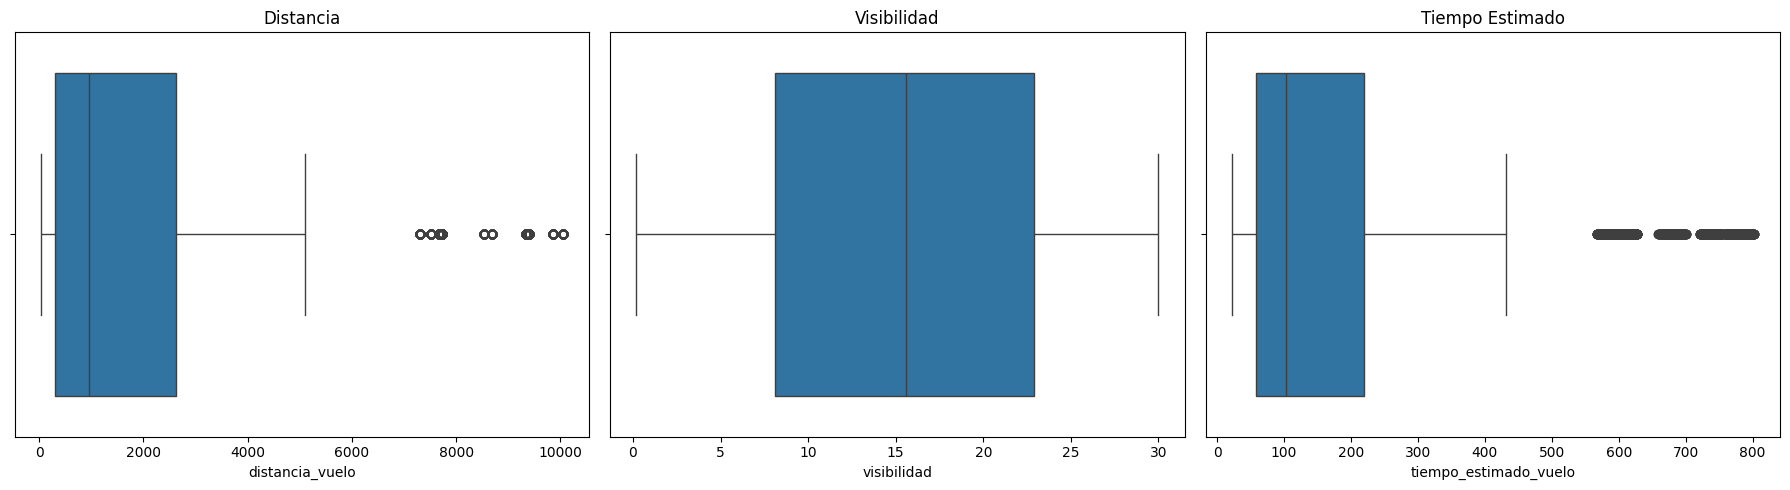

In [ ]:
# Creamos una figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graficamos cada uno en su lugar (usando el argumento 'ax')
sns.boxplot(x=df['distancia_vuelo'], ax=axes[0])
axes[0].set_title('Distancia')

sns.boxplot(x=df['visibilidad'], ax=axes[1])
axes[1].set_title('Visibilidad')

sns.boxplot(x=df['tiempo_estimado_vuelo'], ax=axes[2])
axes[2].set_title('Tiempo Estimado')


plt.tight_layout() # Para que no se encimen los textos
plt.show()

Podemos visualizar que visibilidad no posee outliers y esta contenido entre 7 a 23 aproximadamente.

Por otro lado Distancia tiene algunas distancias muy largas asi como tiempo estimado valores muy altos, realizamos un scatterplot para verificar si hay relacion entre estos valores y verificar que sean correctos.

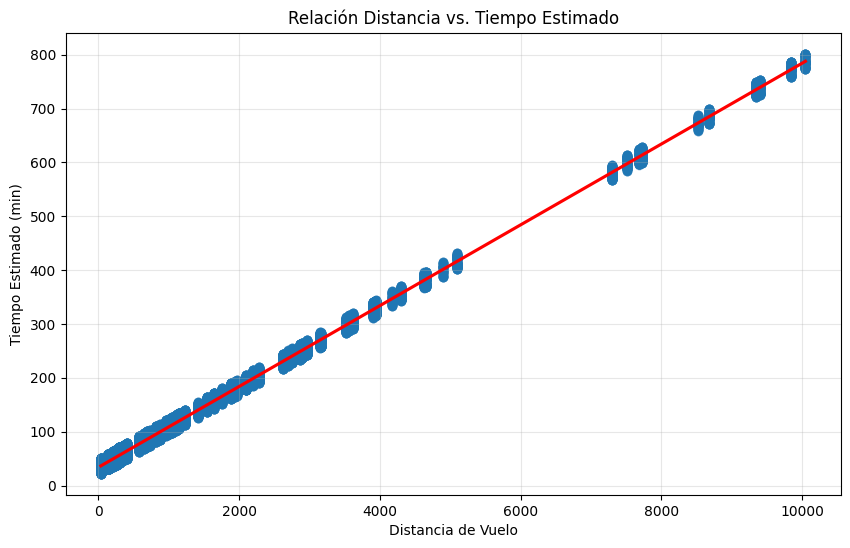

In [ ]:
plt.figure(figsize=(10, 6))
# Usamos regplot para ver la línea de tendencia central
sns.regplot(x='distancia_vuelo', y='tiempo_estimado_vuelo', data=df,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relación Distancia vs. Tiempo Estimado')
plt.xlabel('Distancia de Vuelo')
plt.ylabel('Tiempo Estimado (min)')
plt.grid(True, alpha=0.3)
plt.show()

Confirmamos la correlacion lineal de tiempo estimado de vuelo y la distancia de vuelo, y que las mismas no infieren en la demora.

### Graficos para visualizar relacion de demora segun modelo de avion - condicion climatica

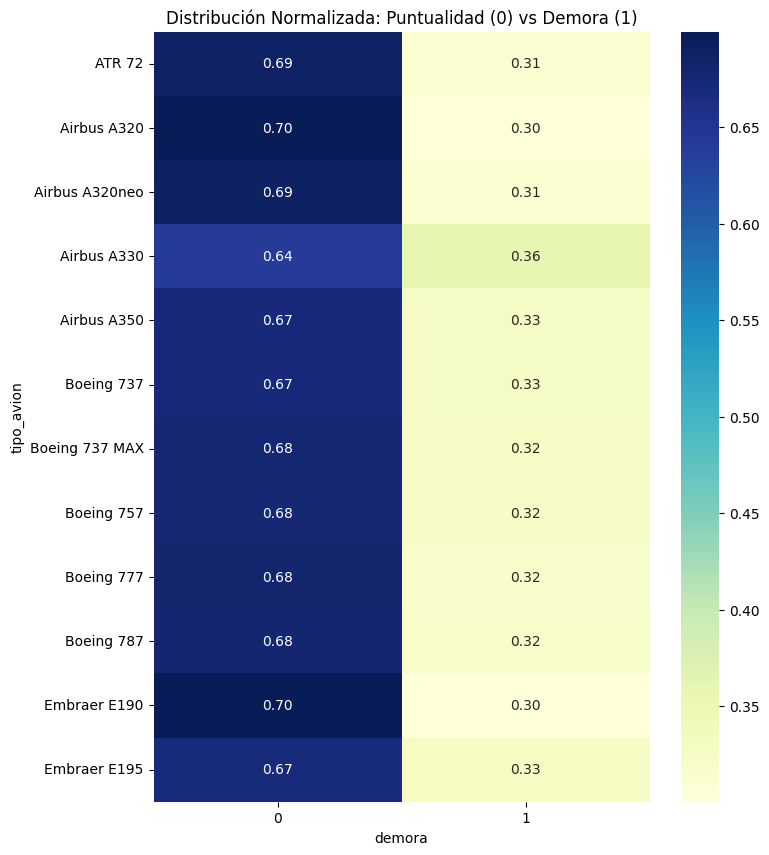

In [ ]:
tabla_contingencia = pd.crosstab(df['tipo_avion'], df['demora'], normalize='index')

plt.figure(figsize=(8, 10))
sns.heatmap(tabla_contingencia, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Distribución Normalizada: Puntualidad (0) vs Demora (1)')
plt.show()

El heatmap nos permite visualizar que hay una proporcion similar de puntualidad y demora para todos los aviones, por lo tanto, esta variable no tendria inferencia en las demoras y puede ser eliminada.
Procedemos a realizar un heatmap para las condiciones del clima

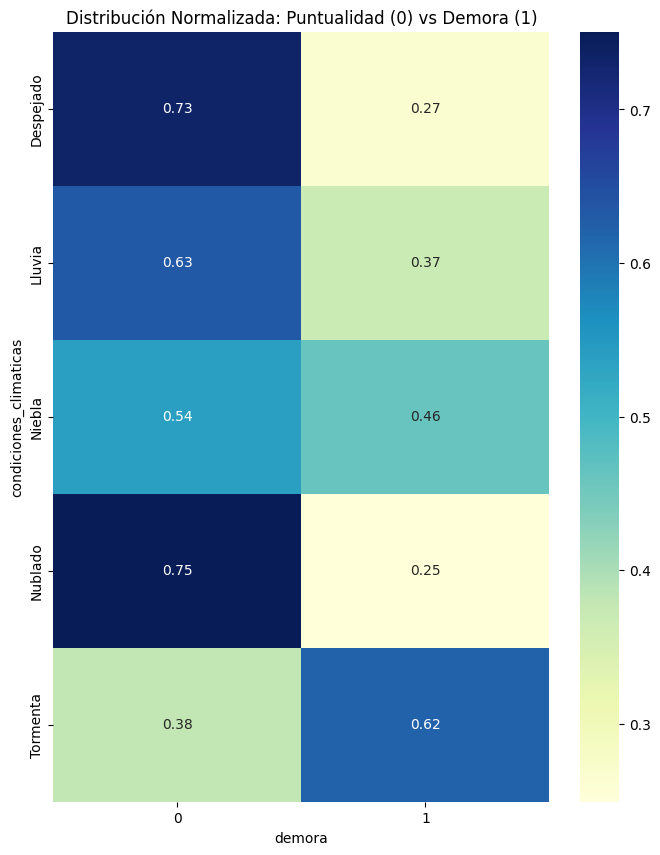

In [ ]:
tabla_clima = pd.crosstab(df['condiciones_climaticas'], df['demora'], normalize='index')

plt.figure(figsize=(8, 10))
sns.heatmap(tabla_clima, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Distribución Normalizada: Puntualidad (0) vs Demora (1)')
plt.show()

Identificamos que hay mayores probabilidades de que haya una demora en casos de tormenta y niebla (en menor medida)
Por lo tanto, las condicioens climaticas son de importancia para la demora y no debe ser imputada.

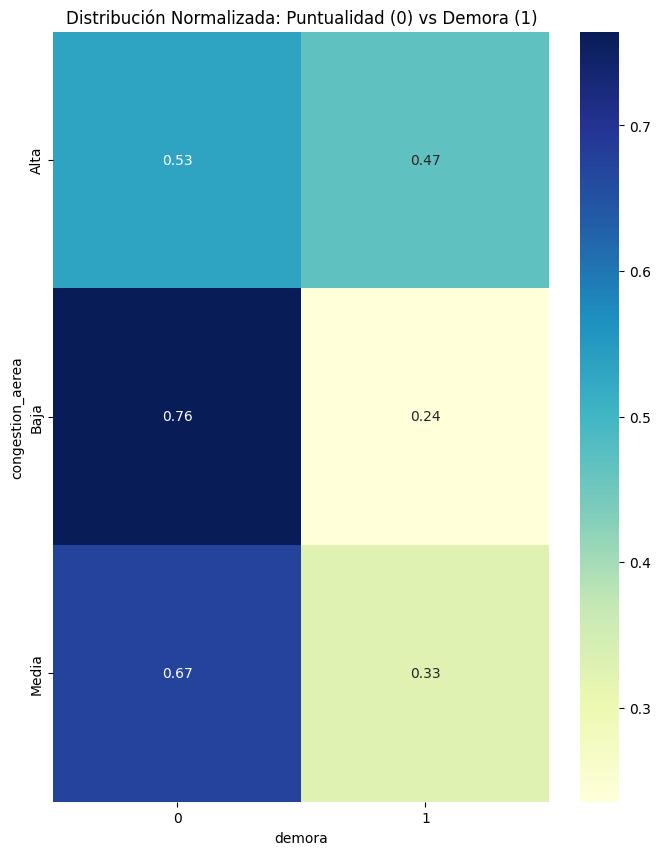

In [ ]:
tabla_congestion = pd.crosstab(df['congestion_aerea'], df['demora'], normalize='index')

plt.figure(figsize=(8, 10))
sns.heatmap(tabla_congestion, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Distribución Normalizada: Puntualidad (0) vs Demora (1)')
plt.show()

Se puede visualizar que con el aumento de la congestion aerea, existen mayores casos de demora, por lo tanto es una columna a tener en cuenta y no debe ser imputada

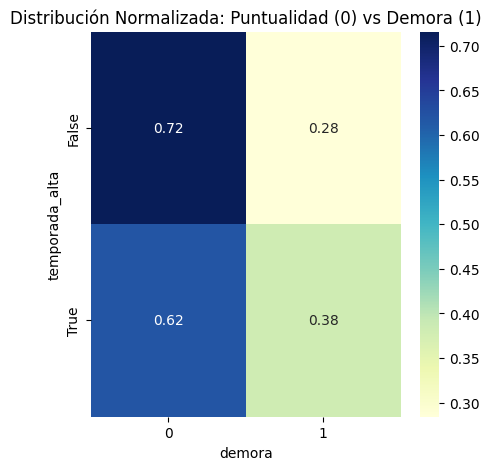

In [ ]:
tabla_temporada = pd.crosstab(df['temporada_alta'], df['demora'], normalize='index')

plt.figure(figsize=(5, 5))
sns.heatmap(tabla_temporada, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Distribución Normalizada: Puntualidad (0) vs Demora (1)')
plt.show()



Se obtiene una mayor demora en casos de temporada alta, pero es tan solo un 0.10 de mejora, podria considerarse como una diferencia marginal.

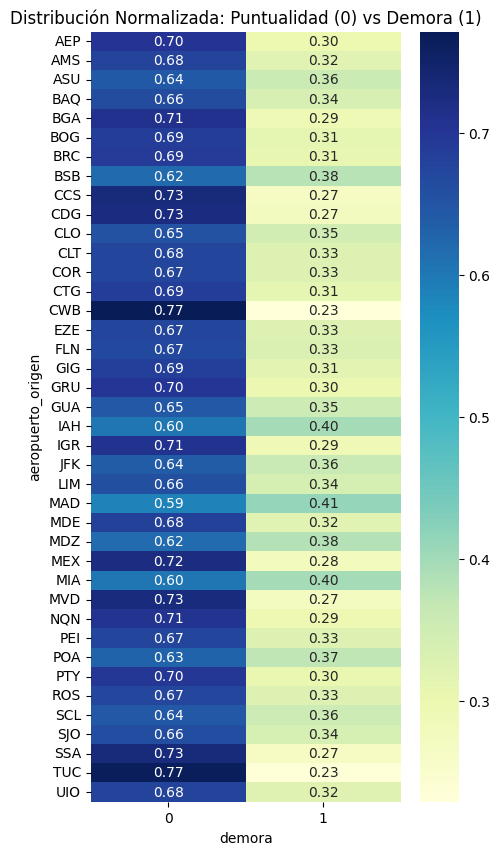

In [ ]:
tabla_orign = pd.crosstab(df['aeropuerto_origen'], df['demora'], normalize='index')

plt.figure(figsize=(5, 10))
sns.heatmap(tabla_orign, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Distribución Normalizada: Puntualidad (0) vs Demora (1)')
plt.show()

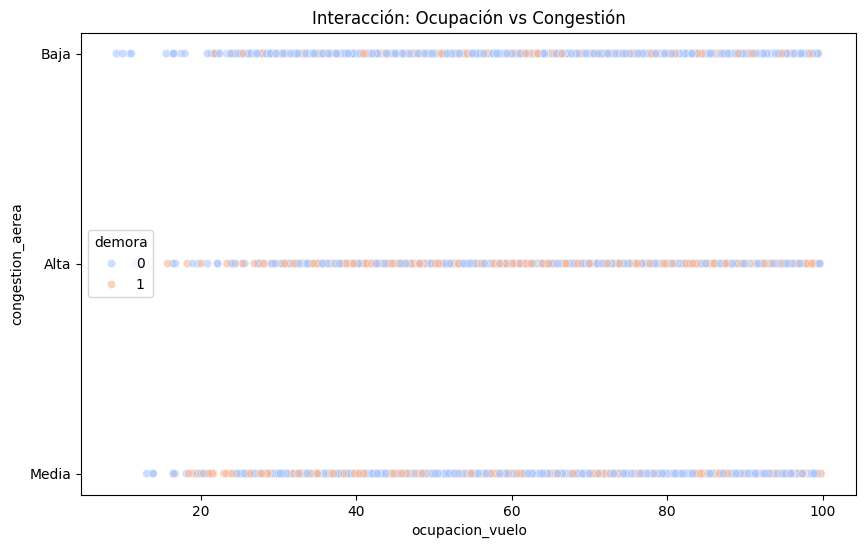

In [ ]:
plt.figure(figsize=(10, 6))
# Gráfico de dispersión coloreado por demora
sns.scatterplot(x='ocupacion_vuelo', y='congestion_aerea', hue='demora',
                data=df, alpha=0.6, palette='coolwarm')

plt.title('Interacción: Ocupación vs Congestión')
plt.show()

## Imputacion de columnas que no aportan informacion (Excel vuelos)

---


Se eliminan columnas como id_vuelo,dia_semana, puerta_embarque, tiempo_estimado,tipo_avion, aeropuerto_origen, aeropuerto_destino

In [ ]:
df = df.drop(columns=['id_vuelo', 'dia_semana', 'puerta_embarque','tiempo_estimado_vuelo','tipo_avion','aeropuerto_origen','aeropuerto_destino'])
df.head()

,hora_salida_programada,distancia_vuelo,condiciones_climaticas,congestion_aerea,ocupacion_vuelo,temporada_alta,visibilidad,demora
0,09:30,360,Despejado,Baja,52.8,False,12.2,1
1,11:00,1230,Despejado,Alta,54.4,True,10.7,1
2,08:15,2280,Niebla,Media,48.7,True,1.0,0
3,06:45,1110,Despejado,Baja,68.0,False,15.8,1
4,11:30,5100,Despejado,Baja,92.0,True,23.0,0
